# Create stamp clasifier training set

In [1]:
import numpy as np
import pandas as pd
import os, re
import matplotlib.pyplot as plt

In [2]:
from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles

from astropy.coordinates import match_coordinates_sky

import astropy.units as u

In [3]:
import astropy.wcs as wcs
import astropy.io.fits as fits

In [5]:
!pip install astroquery

  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached jeepney-0.9.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached jaraco.classes-3.4.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached jaraco_functools-4.3.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached jaraco.context-6.0.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached cffi-2.0.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached backports.tarfile-1.2.0-py3-none-any.whl.metadata (2.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 144.4 MB/s eta 0:00:00
Using cached jeepney-0.9.0-py3-none-any.whl (49 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.9 MB/s eta 0:00:00
Using cached cffi-2.0.0-cp310-cp310-manylinux

In [16]:
from astroquery.hips2fits import hips2fits

In [25]:
datadir = "/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax"

In [26]:
os.listdir(datadir)

['ReadMe',
 'stamps',
 'comm_objs_4candmax.parquet',
 'comm_agn_sne_vs_tran_dup_remove.csv']

# Automatic removal of repeated alerts

In [22]:
df = pd.read_parquet(os.path.join(datadir, "comm_objs_4candmax.parquet"))
counts = df.oid.value_counts()

noid = 0
oids2remove = set()
oids_dict = {}

while True:
    
    df = df.loc[~df.oid.isin(oids2remove)]
    noid_new = df.shape[0]

    # check breaking condition (no change in df)
    if noid == noid_new:
        break

    # create matches dataframe and keep only one example per oid
    matches = pd.DataFrame.from_dict({"oid": df.oid, "ra": df.ra, "dec": df.dec})
    matches = matches.drop_duplicates(subset="oid", keep="first")

    # perform xmatching with itself
    coords = SkyCoord(matches.ra, matches.dec, frame="icrs", unit="deg")
    match = match_coordinates_sky(coords, coords, nthneighbor=2)
    matches["oid_match"] = np.array(matches.iloc[match[0]].oid.to_list())
    matches["distance"] = [float(ang / u.arcsec) for ang in match[1]]
    matches["noid"] = counts.loc[matches.oid].values
    matches["noid_match"] = counts.loc[matches.oid.iloc[match[0]].values].values

    # keep only real matches
    matches = matches.loc[matches.distance < 4]

    # sort by number of counts
    matches = matches.sort_values(by="noid").iloc[::-1]

    # loop over matches and remove matching oid if fewer counts
    for idx in range(len(matches)):
        oid = matches.oid.iloc[idx]
        oid_match = matches.oid_match.iloc[idx]
        noid = counts.loc[oid]
        noid_match = counts.loc[oid_match]
        if noid_match <= noid:
            oids2remove.add(oid_match)
            if oid not in oids_dict.keys():
                oids_dict[oid] = [oid_match]
            else:
                oids_dict[oid].append(oid_match)

    # update size of dataframe
    noid = noid_new

display(matches)

print(len(oids2remove))

pd.DataFrame(oids2remove, columns=["oid"]).to_csv("oids2remove.csv", index=False)

,oid,ra,dec,oid_match,distance,noid,noid_match


451


In [23]:
OUTPUT_CSV = "./oids2remove_angular.csv"

rows = []
for kept_oid, removed_list in oids_dict.items():
    for removed_oid in removed_list:
        rows.append({'oid': removed_oid, 'oid_kept': kept_oid})

df_output = pd.DataFrame(rows)
df_output.to_csv(OUTPUT_CSV, index=False)
print(f"Archivo generado: {OUTPUT_CSV}")

Archivo generado: ./oids2remove_angular.csv


In [24]:
df_output

,oid,oid_kept
0,169298433217659194,169355603113673258
1,169355602459885660,169355602858869595
2,169355602579423428,169355602858869595
3,169355602459885660,169355602728321262
4,169342390938632206,169355602712592487
...,...,...
518,169342391227515000,169342390674915340
519,169342390700605537,169342391905943728
520,169342391610245251,169342390936011001
521,169342390936011001,169342391610245251


## Show distribution before and after removal

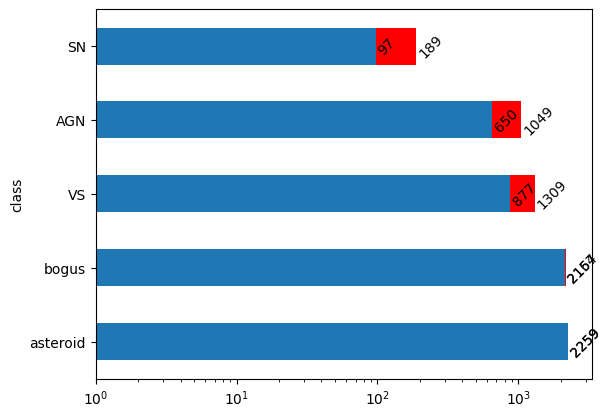

In [20]:
fig, ax = plt.subplots()
df = pd.read_parquet(os.path.join(datadir, "comm_objs_4candmax.parquet"))
df["class"].value_counts().plot.barh(log=True, color='r', ax=ax)
df = df.loc[~df.oid.isin(oids2remove)]
df["class"].value_counts().plot.barh(log=True, ax=ax)
for container in ax.containers:
    ax.bar_label(container, rotation=45)

In [21]:
df

,oid,sid,measurement_id,class,mjd,ra,dec,band,visit,detector,...,shape_flag_parent_source,isDipole,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,3,2025090500225,91,...,False,True,False,False,False,False,False,False,False,False
1,169298432645136566,1,169342390804939401,AGN,60934.116476,8.906227,-44.103605,1,2025091500059,43,...,False,False,False,False,False,False,False,False,False,False
2,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,1,2025091500061,51,...,False,False,False,False,False,False,False,False,False,False
3,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,1,2025091500067,86,...,False,False,False,False,False,False,False,False,False,False
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,3,2025090500254,138,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6963,169623885986660770,1,169623885986660770,bogus,60998.222662,7.275447,-43.372673,2,2025111800209,181,...,False,False,False,False,False,False,False,False,False,False
6964,169623886050099223,1,169623886050099223,bogus,60998.223125,9.959908,-45.02071,2,2025111800210,46,...,False,False,False,False,False,False,False,False,False,False
6965,169623886051672110,1,169623886051672110,bogus,60998.223125,9.650085,-44.784965,2,2025111800210,49,...,False,False,False,False,False,False,False,False,False,False
6966,169623886096236648,1,169623886096236648,bogus,60998.223125,8.584275,-43.367622,2,2025111800210,134,...,False,False,False,False,False,False,False,False,False,False


# Do train test split and stratified folds based on oids

In [12]:
from sklearn.model_selection import train_test_split

aux = df.drop_duplicates(subset="oid")
df_oids = pd.DataFrame()

oid_train, oid_test, cl_train, cl_test = train_test_split(aux.oid.to_numpy(), aux["class"].to_numpy(), test_size=0.2, random_state=42)

df_oids = pd.DataFrame.from_dict({"oid": oid_test, "cl": cl_test, "fold": "test"})

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = skf.split(oid_train, cl_train)

idx_train_folds = {}
idx_val_folds = {}
for idx, f in enumerate(folds):
    idx_train, idx_val = f
    df_oids = pd.concat([df_oids, pd.DataFrame.from_dict({"oid": oid_train[idx_train], "cl": cl_train[idx_train], "fold": f"train_{idx}"})])
    df_oids = pd.concat([df_oids, pd.DataFrame.from_dict({"oid": oid_train[idx_val], "cl": cl_train[idx_val], "fold": f"val_{idx}"})])

In [13]:
df_oids

,oid,cl,fold
0,169368788093894944,VS,test
1,169562329553830036,AGN,test
2,169342396777627696,bogus,test
3,169368783846114197,bogus,test
4,169342395406090501,bogus,test
...,...,...,...
610,169364393924493400,bogus,val_4
611,169368784506191923,bogus,val_4
612,169342391933206625,VS,val_4
613,21163633170198604,asteroid,val_4


Define order for bar plots

In [14]:
cl_order = ["bogus", "asteroid", "VS", "AGN", "SN", "satellite"][::-1]
cl_order = ["bogus", "asteroid", "VS", "AGN", "SN"][::-1]

/tmp/ipykernel_2918507/1099427811.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)


Text(0.5, 1.0, 'Clean oids')

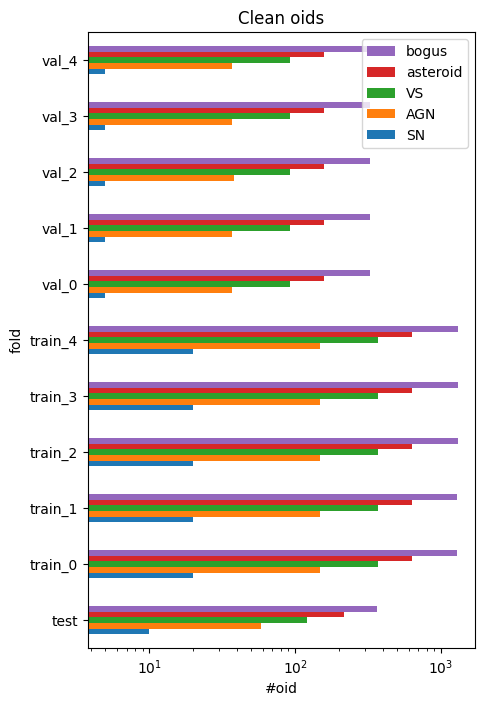

In [15]:
fig, ax = plt.subplots(figsize=(5, 8));
df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)
ax.set_xscale("log")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
ax.set_xlabel("#oid")
ax.set_title("Clean oids")

# Add matching oids to training sets

In [316]:
df_add = []
for idx in range(5):
    mask = (df_oids.fold == f"train_{idx}")
    fold = df_oids.loc[mask]
    oids_train = fold.oid
    oids_add = [[(oid_new, df_oids[df_oids.oid == oid].cl.iloc[0], f"train_{idx}") for oid_new in oids_dict[oid]] for oid in oids_train if oid in oids_dict.keys()]
    df_add.append(pd.DataFrame(data=np.concatenate(oids_add), columns=["oid", "cl", "fold"]))
df_add = pd.concat(df_add, axis=0)
display(df_add)
df_oids = pd.concat([df_oids, df_add])

,oid,cl,fold
0,169364393025339517,VS,train_0
1,169342390940205071,AGN,train_0
2,169342391326081133,AGN,train_0
3,169342390786588782,AGN,train_0
4,169342390657089653,AGN,train_0
...,...,...,...
95,169342391131046160,VS,train_4
96,169342391399481686,VS,train_4
97,169364391030948024,VS,train_4
98,169342391326605374,AGN,train_4


/tmp/ipykernel_347906/2172516165.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)


Text(0.5, 1.0, 'Matching oids added to training sets')

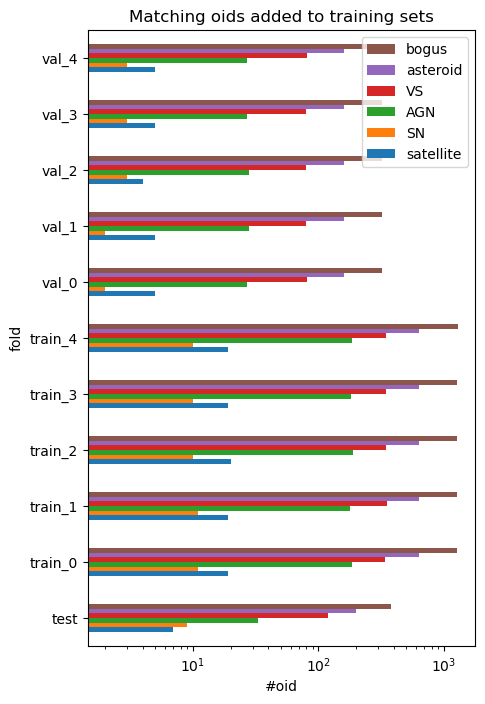

In [318]:
fig, ax = plt.subplots(figsize=(5, 8));
df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)
ax.set_xscale("log")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
ax.set_xlabel("#oid")
ax.set_title("Matching oids added to training sets")

# Add measurement ids

In [319]:
df_orig = pd.read_parquet(os.path.join(datadir, "comm_objs_4candmax.parquet"))

In [320]:
df_oids = df_orig[["oid", "measurement_id"]].merge(df_oids, on="oid")

/tmp/ipykernel_347906/3882029750.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)


Text(0.5, 1.0, 'Measurement ids added to all sets')

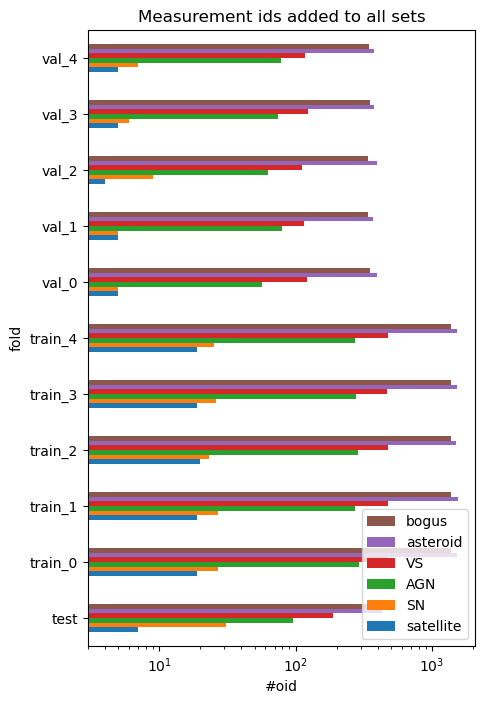

In [321]:
fig, ax = plt.subplots(figsize=(5, 8));
df_oids.groupby(["fold", "cl"]).apply(lambda df: df.shape[0]).reset_index(name="count").pivot(index="fold", columns="cl", values="count")[cl_order].plot.barh(ax=ax)
ax.set_xscale("log")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
ax.set_xlabel("#oid")
ax.set_title("Measurement ids added to all sets")

## Save final fold

In [301]:
df_oids = df_oids.sort_values(by=["fold", "cl"])
df_oids.to_csv("stamp_folds.csv", index=False)

In [302]:
df_oids

,oid,measurement_id,cl,fold
0,169298432645136566,169298432645136566,AGN,test
1,169298432645136566,169342391077569156,AGN,test
2,169298432645136566,169342391901225029,AGN,test
3,169298432645136566,169355603629573036,AGN,test
109,169302854308200461,169302854308200461,AGN,test
...,...,...,...,...
24245,169368784704897048,169368784704897048,satellite,val_4
24250,169368784704897054,169368784704897054,satellite,val_4
24298,169368786715017293,169368786715017293,satellite,val_4
24303,169368786715017301,169368786715017301,satellite,val_4


# Download Legacy Survey images

In [12]:
df.head()

,oid,sid,measurement_id,class,mjd,ra,dec,band,visit,detector,...,shape_flag_parent_source,isDipole,pixelFlags_crCenter,pixelFlags_nodataCenter,pixelFlags_interpolatedCenter,pixelFlags_saturatedCenter,pixelFlags_suspectCenter,pixelFlags_streakCenter,pixelFlags_injectedCenter,pixelFlags_injected_templateCenter
0,169298432645136566,1,169298432645136566,AGN,60924.330414,8.905992,-44.103805,3,2025090500225,91,...,False,True,False,False,False,False,False,False,False,False
1,169298432645136566,1,169342391077569156,AGN,60934.11739,8.906245,-44.103744,1,2025091500061,51,...,False,False,False,False,False,False,False,False,False,False
2,169298432645136566,1,169342391901225029,AGN,60934.120075,8.906182,-44.103707,1,2025091500067,86,...,False,False,False,False,False,False,False,False,False,False
3,169298432645136566,1,169355603629573036,AGN,60937.255982,8.906043,-44.103807,1,2025091800198,98,...,False,False,False,False,False,False,False,False,False,False
4,169298436562092346,1,169298436562092346,AGN,60924.363906,9.721266,-43.055253,3,2025090500254,138,...,False,True,False,False,False,False,False,False,False,False


In [13]:
band = 'g'

def get_LS_r_multires(ra, dec, nlevels):

    cdelt_arcsec = 0.25
    filenames = {}
    for i in range(nlevels):
        w = wcs.WCS(header={
    	'NAXIS': 2,
    	'NAXIS1': 30,       
    	'NAXIS2': 30,       
    	'CTYPE1': 'RA---TAN',
    	'CTYPE2': 'DEC--TAN',
    	'CDELT1': (cdelt_arcsec / 3600 * 2**i),
    	'CDELT2': (cdelt_arcsec / 3600 * 2**i),
    	'CRPIX1': 15.0,
    	'CRPIX2': 15.0,
    	'CUNIT1': 'deg',
    	'CUNIT2': 'deg',
    	'CRVAL1': ra,
    	'CRVAL2': dec,
    	'PC1_1': -1.,
    	'PC1_2': 0.,
    	'PC2_1': 0.,
    	'PC2_2': 1.
    	})
        hips = f"CDS/P/DESI-Legacy-Surveys/DR10/{band}"
        result = hips2fits.query_with_wcs(
            hips=hips,
            wcs=w,
            get_query_payload=False,
            format='fits')
        filenames[i] = os.path.join(downloadfolder, f"stack_{band}_{oid}_level{i}.fits")
        if np.sum(np.isnan(result[0].data)) / np.shape(result[0].data)[0] / np.shape(result[0].data)[1] > 0.5:
            print(f"WARNING: More than half of the pixels of {filenames[i]} are NaN values.")
            open(f"{filenames[i]}.error", "a").close()
        result.writeto(filenames[i], overwrite=True)
        print(f"Downloaded {filenames[i]} using HiPS2Fits.")

    return filenames

In [14]:
downloadfolder = "lsimages"
if not os.path.exists(downloadfolder):
    os.makedirs(downloadfolder)

In [18]:
nlevels = 5
counter = 0
for oid in df.oid.unique():
    counter += 1
    print(f"{counter}/{df.oid.unique().shape[0]}")
    
    skip = False
    for i in range(nlevels):
        if not skip and os.path.exists(os.path.join(downloadfolder, f"stack_{band}_{oid}_level{i}.fits")):
            skip = True
    #print(f"Skipping {oid}")
    if skip:
        continue

    mask = (df.oid == oid)
    #print(df.loc[mask][["ra", "dec"]])
    multires = get_LS_r_multires(df.loc[mask].ra.values[0], df.loc[mask].dec.values[0], nlevels)
    fig, ax = plt.subplots(ncols=nlevels, figsize=(nlevels*3, 3))
    for i in range(nlevels):
        ax[i].imshow(fits.open(multires[i])[0].data.byteswap().newbyteorder(), interpolation='nearest')
        ax[i].set_title(df.loc[mask]["class"].values[0])
    plt.show()

1/3732
2/3732
3/3732
4/3732
5/3732
6/3732
7/3732
8/3732
9/3732
10/3732
11/3732
12/3732
13/3732
14/3732
15/3732
16/3732
17/3732
18/3732
19/3732
20/3732
21/3732
22/3732
23/3732
24/3732
25/3732
26/3732
27/3732
28/3732
29/3732
30/3732
31/3732
32/3732
33/3732
34/3732
35/3732
36/3732
37/3732
38/3732
39/3732
40/3732
41/3732
42/3732
43/3732
44/3732
45/3732
46/3732
47/3732
48/3732
49/3732
50/3732
51/3732
52/3732
53/3732
54/3732
55/3732
56/3732
57/3732
58/3732
59/3732
60/3732
61/3732
62/3732
63/3732
64/3732
65/3732
66/3732
67/3732
68/3732
69/3732
70/3732
71/3732
72/3732
73/3732
74/3732
75/3732
76/3732
77/3732
78/3732
79/3732
80/3732
81/3732
82/3732
83/3732
84/3732
85/3732
86/3732
87/3732
88/3732
89/3732
90/3732
91/3732
92/3732
93/3732
94/3732
95/3732
96/3732
97/3732
98/3732
99/3732
100/3732
101/3732
102/3732
103/3732
104/3732
105/3732
106/3732
107/3732
108/3732
109/3732
110/3732
111/3732
112/3732
113/3732
114/3732
115/3732
116/3732
117/3732
118/3732
119/3732
120/3732
121/3732
122/3732
123/3732
1

## Check the distribution of matched positions

In [ ]:
df = pd.read_parquet(os.path.join(datadir, "comm_objs_4candmax.parquet"))

In [19]:
files = sorted(os.listdir(os.path.join(downloadfolder)))

4118 5
4130 1630


Text(0, 0.5, 'Dec [deg]')

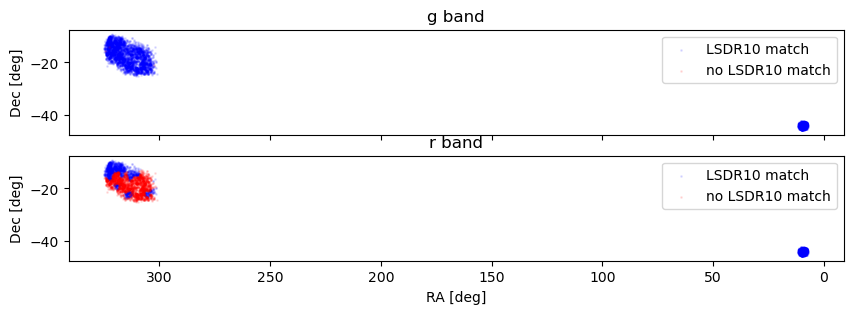

In [22]:
fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(10, 3))
for idx, bandsearch in enumerate(["g", "r"]):
    oids = re.findall(f"stack_{bandsearch}_(.*?)_level0.fits", "\n".join(files))
    oids_error = re.findall(f"stack_{bandsearch}_(.*?)_level0.fits.error", "\n".join(files))
    oids = set(oids)
    oids_error = set(oids_error)
    print(len(oids), len(oids_error))
    oids = oids.difference(oids_error)
    len(oids)
    ax[idx].scatter(df.loc[df.oid.isin(oids)].ra, df.loc[df.oid.isin(oids)].dec, s=1, color='b', alpha=0.1, label="LSDR10 match")
    ax[idx].scatter(df.loc[df.oid.isin(oids_error)].ra, df.loc[df.oid.isin(oids_error)].dec, s=1, color='r', alpha=0.1, label="no LSDR10 match")
    ax[idx].set_title(f"{bandsearch} band")
    ax[idx].legend()
ax[0].set_xlim(ax[0].get_xlim()[::-1])
ax[1].set_xlabel("RA [deg]")
ax[0].set_ylabel("Dec [deg]")
ax[1].set_ylabel("Dec [deg]")


# Load stamps

In [10]:
stamps = []
for f in sorted(os.listdir(os.path.join(datadir, "stamps"))):
    print(f)
    stamps.append(pd.read_pickle(os.path.join(datadir, "stamps", f)))
stamps = pd.concat(stamps)
stamps = stamps.loc[stamps.oid.isin(df.oid)]

chunk0000_stamps.pkl
chunk0001_stamps.pkl
chunk0002_stamps.pkl
chunk0003_stamps.pkl
chunk0004_stamps.pkl
chunk0005_stamps.pkl
chunk0006_stamps.pkl
chunk0007_stamps.pkl
chunk0008_stamps.pkl
chunk0009_stamps.pkl
chunk0010_stamps.pkl
chunk0011_stamps.pkl
chunk0012_stamps.pkl
chunk0013_stamps.pkl
chunk0014_stamps.pkl
chunk0015_stamps.pkl
chunk0016_stamps.pkl
chunk0017_stamps.pkl
chunk0018_stamps.pkl
chunk0019_stamps.pkl
chunk0020_stamps.pkl
chunk0021_stamps.pkl
chunk0022_stamps.pkl
chunk0023_stamps.pkl
chunk0024_stamps.pkl
chunk0025_stamps.pkl
chunk0026_stamps.pkl
chunk0027_stamps.pkl
chunk0028_stamps.pkl
chunk0029_stamps.pkl
chunk0030_stamps.pkl
chunk0031_stamps.pkl
chunk0032_stamps.pkl
chunk0033_stamps.pkl
chunk0034_stamps.pkl
chunk0035_stamps.pkl
chunk0036_stamps.pkl
chunk0037_stamps.pkl
chunk0038_stamps.pkl
chunk0039_stamps.pkl
chunk0040_stamps.pkl
chunk0041_stamps.pkl


In [11]:
stamps.head(1)

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169298432645136566,169298432645136566,"[[-11.944677, 22.680063, 56.766247, -69.47594,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[12.199259, 13.337936, 4.610951, 12.187733, 1...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-32.02772, -3.1861129, 29.517363, -62.336437...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[2029.274, 2043.5964, 2039.1626, 1984.181, 20...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[45.872807, 35.292248, 44.605923, 42.904793, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[2033.2526, 1985.2286, 2034.6351, 1976.9246, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.10...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.10...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
